In [27]:

# NOTE
# Use training, test, validation sets

# Task 1.1
# Apply test data. Calculate differences between original and reconstructed patches
# With beta and with no beta

# Task 1.2
# Plot latent vector distribution for the mean matrix

# Task 1.3 
# Plot the curve for KL divergence

# Task 1.4
# Filter out empty patches


In [28]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm
from torch.utils.data import random_split


In [29]:
# References
# https://datatas.com/how-to-use-variational-autoencoders-for-large-scale-data-compression/

In [30]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
BITS_HIT = 25

In [31]:
def show_image(events: np.array) -> None:
    image_plot = events.to_images()[0][1]
    plt.imshow(image_plot, cmap='gist_yarg', origin='lower')
    plt.show()
    
def _tensor_to_numpy(values: torch.Tensor) -> np.array:
    return values.cpu().detach().numpy()

def plot_patch(patch: np.array, title: str) -> None:
    plt.imshow(patch, cmap='gist_yarg', origin='lower')
    plt.title(title)
    plt.show()
    
def _get_encoded_patch_bits(encoded_size,
                           patch_size,
                           module_rows=160,
                           module_cols=416):
    
    encoded_width, encoded_height, num_embeddings = encoded_size
    # print(encoded_width, encoded_height, np.log2(num_embeddings))
    vq_bits = encoded_width * encoded_height * np.log2(num_embeddings)
    
    # Patch address bits
    bits_patch_row = np.ceil(np.log2(np.ceil(module_rows / patch_size)))
    bits_patch_col = np.ceil(np.log2(np.ceil(module_cols / patch_size)))
    total = bits_patch_row + bits_patch_col + vq_bits
    
    # 267 % 256 = 11
    return total.astype(np.uint8)

def _get_total_hit_bits(total_hits: int) -> int:
    
    # Patch address bits
    return total_hits * BITS_HIT

def _get_total_patch_bits(patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> int:
    encoded_patch_bits = _get_encoded_patch_bits(encoded_patch_size, patch_size)
    return np.uint64(patch_amount) * encoded_patch_bits

# TODO: test the method
def _get_compression_ratio(n_hits_total: int, patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> float:
    
    total_bits = _get_total_hit_bits(n_hits_total)
    total_patch_bits = _get_total_patch_bits(
        patch_amount, 
        encoded_patch_size, 
        patch_size
    )
    return total_bits / total_patch_bits

def _get_patch_count(event: PixelDigiEvent) -> int:
    event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
    event_patches_adcs = [
        event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
        for event_patch_flat in event_patches_adcs_flat
    ]
    return len(event_patches_adcs)

    
# helper function
def _display_gradients(model: object) -> None:
    print("Showing model gradients")
    for name, param in model.named_parameters():
        if param.grad is not None:
            print(name, param.grad.norm().item())
            
def plot_metric_results(
    y_values: list[float], 
    x_values: int, 
    y_title: str, 
    title: str,
    x_label: str,
    marker: str=None
) -> None:
    print(title + " values over epochs")
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(8, 5))
    plt.plot(x_values, y_values, marker=marker)
    plt.xlabel(x_label)
    plt.ylabel(y_title)
    plt.legend()
    plt.title(title)
    plt.show()

In [32]:
# Loading data

pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:04<00:00, 239.62it/s]


In [33]:
batch_size = 64
beta = 0
beta = 1e-5
learning_rate = 1e-3
num_epochs = 80
channels = 1
latent_dim = 128

# Comment:
# Need to use bigger latent dimension. Bigger than 16. Wider latent dimension,
# the more information is preserved after matrix transformations
# If latent dimension = 16, than noisy outputs from encoder

# num_embeddings = 256 
LOG_EVERY = 10


In [34]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [35]:
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

In [36]:
event_train = events_train[:SELECTED_EVENTS][0]

In [37]:
class PixelPatchesDataset(torch.utils.data.Dataset):
    def __init__(self, event: PixelDigiEvent, transform=None):
        event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
        self.event_patches_adcs = [
            event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
            for event_patch_flat in event_patches_adcs_flat
            if not (np.all(event_patch_flat == 0))
        ]
        
        self.transform = transform

    # Defining the length of the dataset
    def __len__(self) -> int:
        return len(self.event_patches_adcs)

    # Defining the method to get an item from the dataset
    def __getitem__(self, index: int) -> np.array:
        # print(self.event_patches_adcs[index])
        event_patch = self.event_patches_adcs[index]
        
        # Applying the transform
        if self.transform:
            event_patch = self.transform(event_patch)
            # print(event_patch)
        
        return event_patch

In [38]:
# Data preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0], std=[1])    
])

event_dataset = PixelPatchesDataset(event_train, transform)
dataset_size = len(event_dataset)

train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    event_dataset,
    [train_size, val_size, test_size]
)

# # Training data prepearation

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset, 
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=batch_size,
    shuffle=False
)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

# train_loader = DataLoader(
#     dataset=event_dataset, 
#     batch_size=batch_size
# )

# # Test data preparation
# events_test_loaders = []
# for event_test in events_test:
#     event_dataset = PixelPatchesDataset(event_test, transform)

#     event_test_loader = DataLoader(
#         dataset=event_dataset, 
#         batch_size=batch_size
#     )
#     events_test_loaders.append(event_test_loader)

Training set size: 12685
Validation set size: 1585
Test set size: 1587


In [39]:
def _get_vae_loss(
    recon_x: torch.tensor, 
    x: torch.tensor, 
    mu: torch.tensor, 
    logvar: torch.tensor
) -> float:
    # recon_loss = F.mse_loss(
    #     recon_x, 
    #     x, 
    #     reduction="sum"
    # ) / x.size(0)
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="mean")
    
    # KL_divergence
    kl_loss = -0.5 * (
        1 + logvar - mu.pow(2) - logvar.exp()
    )
    
    kl_loss = kl_loss.mean()
    
    return (
        recon_loss + beta * kl_loss,
        recon_loss,
        beta,
        kl_loss
    )

In [40]:
# Comments
# kernel_size = 4 - preserves spatial repesentations (coordinates)
class VAE(nn.Module):
    
    def __init__(
        self, 
        hidden_channels: int, 
        kernel_size: int, 
        slope: float
    ) -> None:
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),  
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),            
            nn.Conv2d(hidden_channels * 2, hidden_channels * 2, kernel_size=kernel_size-1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),
        )
        # self.flatten = nn.Flatten()
        self.fc_mean = nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=1)
        self.fc_log_var = nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=1)
        # self.fc_mean = nn.Linear(
        #     hidden_channels * 2 * PATCH_SIZE//4 * PATCH_SIZE//4, 
        #     latent_dim * 4
        # )
        torch.nn.init.xavier_uniform_(self.fc_mean.weight)
        
        # self.fc_log_var = nn.Linear(
        #     hidden_channels * 2 * PATCH_SIZE//4 * PATCH_SIZE//4, 
        #     latent_dim * 4
        # )        
        torch.nn.init.xavier_uniform_(self.fc_log_var.weight)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=kernel_size - 1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.Sigmoid()
        )
    
    def reparameterize(self, mu, logvar):
        return mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        
        
    def forward(self, x):
        # apply convolutional layers with relu activation function
        # print("x range:", x.min().item(), x.max().item())
        
        x_encoded = self.encoder(x)
        
        # x_flatten = self.flatten(x_encoded)
        
        # get the mean and log variance of the latent space distribution
        z_log_mean = self.fc_mean(x_encoded)
        z_log_var = self.fc_log_var(x_encoded)
        
        self.z_log_mean = torch.clamp(z_log_mean, min=-10, max=10)
        # self.z_log_var = torch.clamp(z_log_var, min=-8, max=1)
        self.z_log_var = torch.tanh(z_log_var) * 8
        
        # sample a latent vector using the reparameterization trick
        
        z = self.reparameterize(self.z_log_mean, self.z_log_var)
        
        output = self.decoder(z)
        
        return output, self.z_log_mean, self.z_log_var

In [41]:
model = VAE(
    hidden_channels=64, 
    kernel_size = 4,
    slope=0.01
).to(device)

optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

Epoch 1/80: 100%|██████████| 199/199 [00:00<00:00, 544.55it/s, Loss=0.0309]


Epoch [1/80] Average Loss: 0.0726
Average validation set MSE loss: 3292.48404296875
Last validation batch patch mu and logvar:
mu: mean=0.0104, std=0.5887 | logvar: mean=-6.0138, std=1.5948
Before compression
Before: (64, 8, 8)


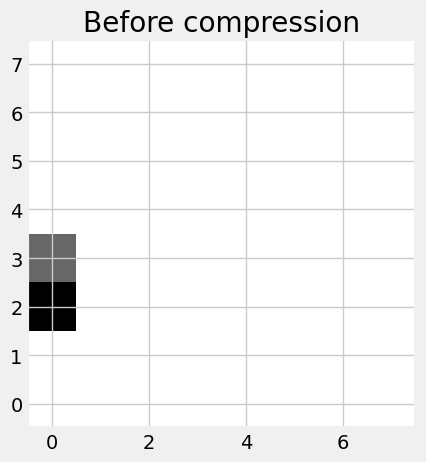

After: (1, 8, 8)
After compression


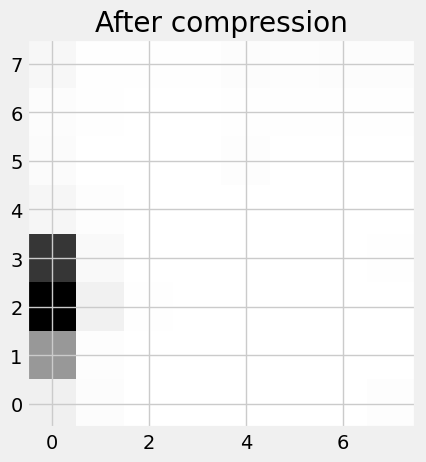

Epoch 2/80: 100%|██████████| 199/199 [00:00<00:00, 546.58it/s, Loss=0.0551]


Epoch [2/80] Average Loss: 0.0372


Epoch 3/80: 100%|██████████| 199/199 [00:00<00:00, 548.50it/s, Loss=0.0336]


Epoch [3/80] Average Loss: 0.0336


Epoch 4/80: 100%|██████████| 199/199 [00:00<00:00, 552.46it/s, Loss=0.0273]


...

Epoch [9/80] Average Loss: 0.0295


Epoch 10/80: 100%|██████████| 199/199 [00:00<00:00, 549.86it/s, Loss=0.0315]


Epoch [10/80] Average Loss: 0.0293


Epoch 11/80: 100%|██████████| 199/199 [00:00<00:00, 548.75it/s, Loss=0.0224]


Epoch [11/80] Average Loss: 0.0291
Average validation set MSE loss: 722.5330358886719
Last validation batch patch mu and logvar:
mu: mean=0.0213, std=0.7906 | logvar: mean=-6.8961, std=1.1418
Before compression
Before: (64, 8, 8)


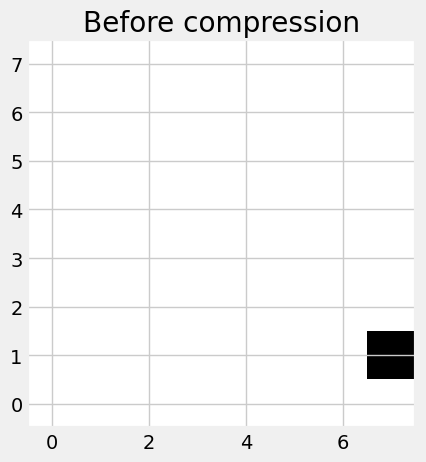

After: (1, 8, 8)
After compression


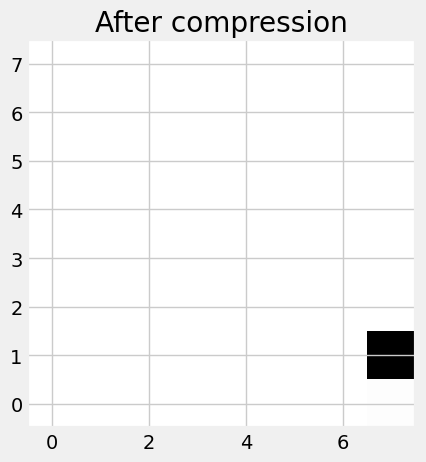

Epoch 12/80: 100%|██████████| 199/199 [00:00<00:00, 555.61it/s, Loss=0.0264]


Epoch [12/80] Average Loss: 0.0289


Epoch 13/80: 100%|██████████| 199/199 [00:00<00:00, 544.78it/s, Loss=0.0367]


Epoch [13/80] Average Loss: 0.0287


Epoch 14/80: 100%|██████████| 199/199 [00:00<00:00, 530.28it/s, Loss=0.0374]


...

Epoch [19/80] Average Loss: 0.0278


Epoch 20/80: 100%|██████████| 199/199 [00:00<00:00, 553.17it/s, Loss=0.0341]


Epoch [20/80] Average Loss: 0.0278


Epoch 21/80: 100%|██████████| 199/199 [00:00<00:00, 552.88it/s, Loss=0.0373]


Epoch [21/80] Average Loss: 0.0278
Average validation set MSE loss: 627.5156005859375
Last validation batch patch mu and logvar:
mu: mean=0.0287, std=0.8548 | logvar: mean=-6.9351, std=1.1423
Before compression
Before: (64, 8, 8)


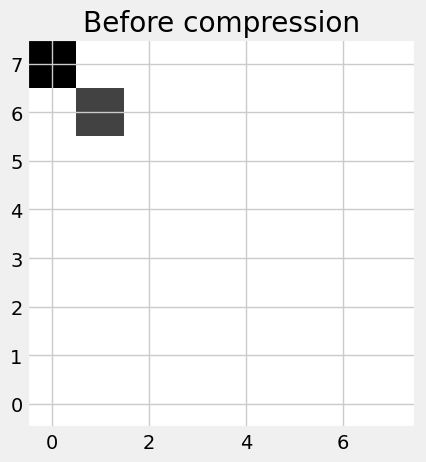

After: (1, 8, 8)
After compression


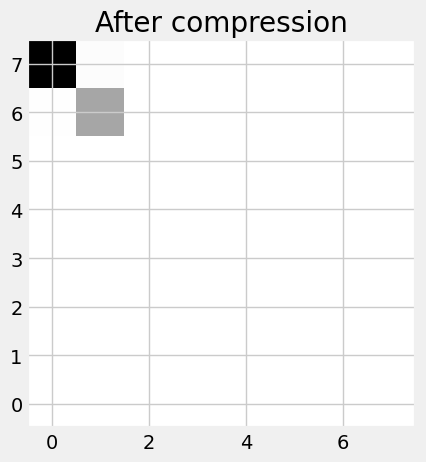

Epoch 22/80: 100%|██████████| 199/199 [00:00<00:00, 548.22it/s, Loss=0.0295]


Epoch [22/80] Average Loss: 0.0276


Epoch 23/80: 100%|██████████| 199/199 [00:00<00:00, 548.76it/s, Loss=0.0332]


Epoch [23/80] Average Loss: 0.0275


Epoch 24/80: 100%|██████████| 199/199 [00:00<00:00, 537.13it/s, Loss=0.0255]


...

Epoch [29/80] Average Loss: 0.0270


Epoch 30/80: 100%|██████████| 199/199 [00:00<00:00, 543.25it/s, Loss=0.0243]


Epoch [30/80] Average Loss: 0.0269


Epoch 31/80: 100%|██████████| 199/199 [00:00<00:00, 549.25it/s, Loss=0.0222]


Epoch [31/80] Average Loss: 0.0268
Average validation set MSE loss: 522.329848022461
Last validation batch patch mu and logvar:
mu: mean=0.0182, std=0.8866 | logvar: mean=-6.9236, std=1.1600
Before compression
Before: (64, 8, 8)


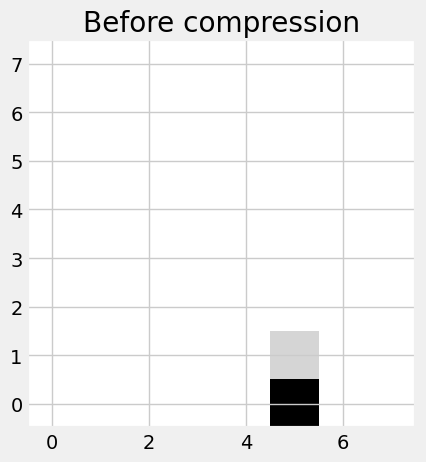

After: (1, 8, 8)
After compression


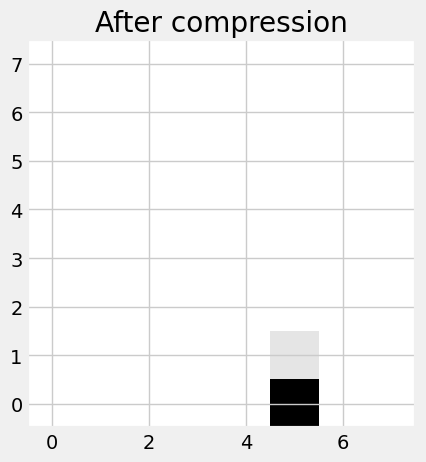

Epoch 32/80: 100%|██████████| 199/199 [00:00<00:00, 543.37it/s, Loss=0.0177]


Epoch [32/80] Average Loss: 0.0267


Epoch 33/80: 100%|██████████| 199/199 [00:00<00:00, 546.03it/s, Loss=0.037] 


Epoch [33/80] Average Loss: 0.0267


Epoch 34/80: 100%|██████████| 199/199 [00:00<00:00, 526.13it/s, Loss=0.0348]


...

Epoch [39/80] Average Loss: 0.0261


Epoch 40/80: 100%|██████████| 199/199 [00:00<00:00, 555.28it/s, Loss=0.0311]


Epoch [40/80] Average Loss: 0.0260


Epoch 41/80: 100%|██████████| 199/199 [00:00<00:00, 558.86it/s, Loss=0.02]  


Epoch [41/80] Average Loss: 0.0259
Average validation set MSE loss: 380.7130700683594
Last validation batch patch mu and logvar:
mu: mean=0.0285, std=0.8930 | logvar: mean=-6.8887, std=1.1699
Before compression
Before: (64, 8, 8)


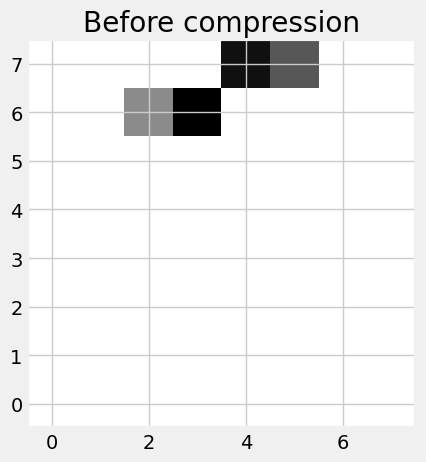

After: (1, 8, 8)
After compression


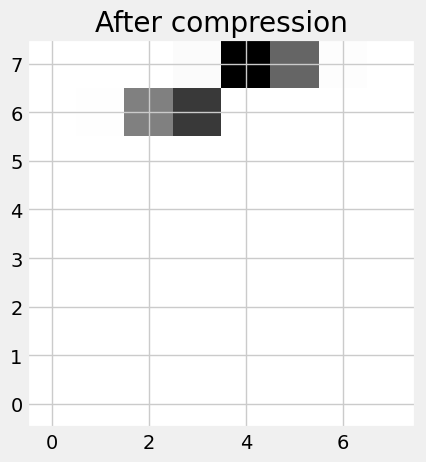

Epoch 42/80: 100%|██████████| 199/199 [00:00<00:00, 558.78it/s, Loss=0.0235]


Epoch [42/80] Average Loss: 0.0258


Epoch 43/80: 100%|██████████| 199/199 [00:00<00:00, 561.76it/s, Loss=0.027] 


Epoch [43/80] Average Loss: 0.0258


Epoch 44/80: 100%|██████████| 199/199 [00:00<00:00, 573.45it/s, Loss=0.0307]


...

Epoch [49/80] Average Loss: 0.0256


Epoch 50/80: 100%|██████████| 199/199 [00:00<00:00, 543.27it/s, Loss=0.025] 


Epoch [50/80] Average Loss: 0.0256


Epoch 51/80: 100%|██████████| 199/199 [00:00<00:00, 548.45it/s, Loss=0.0334]


Epoch [51/80] Average Loss: 0.0256
Average validation set MSE loss: 293.38147399902346
Last validation batch patch mu and logvar:
mu: mean=0.0282, std=0.8719 | logvar: mean=-6.9076, std=1.1241
Before compression
Before: (64, 8, 8)


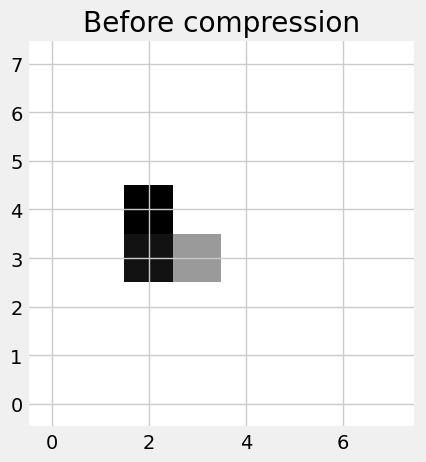

After: (1, 8, 8)
After compression


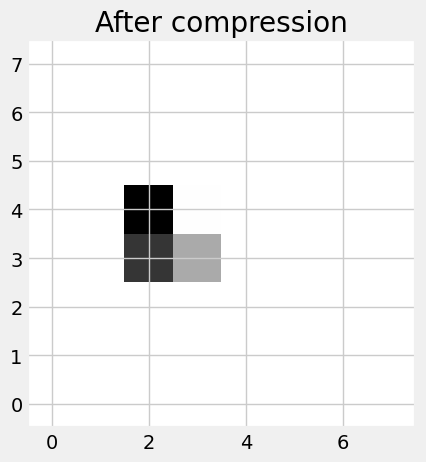

Epoch 52/80: 100%|██████████| 199/199 [00:00<00:00, 549.85it/s, Loss=0.0266]


Epoch [52/80] Average Loss: 0.0256


Epoch 53/80: 100%|██████████| 199/199 [00:00<00:00, 554.26it/s, Loss=0.0187]


Epoch [53/80] Average Loss: 0.0255


Epoch 54/80: 100%|██████████| 199/199 [00:00<00:00, 558.98it/s, Loss=0.039] 


...

Epoch [59/80] Average Loss: 0.0255


Epoch 60/80: 100%|██████████| 199/199 [00:00<00:00, 562.18it/s, Loss=0.0284]


Epoch [60/80] Average Loss: 0.0255


Epoch 61/80: 100%|██████████| 199/199 [00:00<00:00, 550.80it/s, Loss=0.0174]


Epoch [61/80] Average Loss: 0.0254
Average validation set MSE loss: 274.9308416748047
Last validation batch patch mu and logvar:
mu: mean=0.0304, std=0.8650 | logvar: mean=-6.8911, std=1.1192
Before compression
Before: (64, 8, 8)


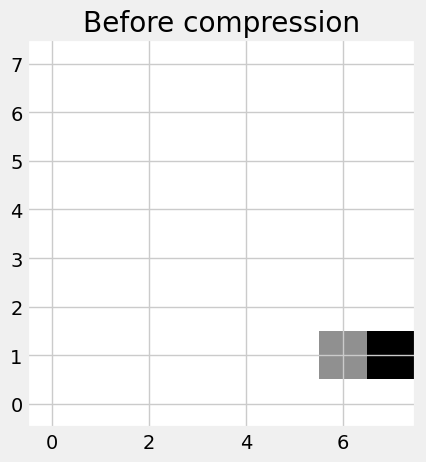

After: (1, 8, 8)
After compression


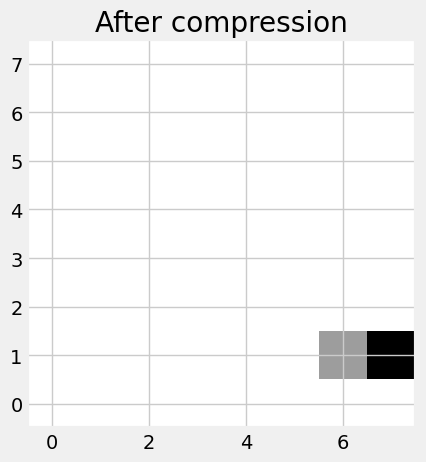

Epoch 62/80: 100%|██████████| 199/199 [00:00<00:00, 546.22it/s, Loss=0.0315]


Epoch [62/80] Average Loss: 0.0255


Epoch 63/80: 100%|██████████| 199/199 [00:00<00:00, 553.77it/s, Loss=0.0287]


Epoch [63/80] Average Loss: 0.0255


Epoch 64/80: 100%|██████████| 199/199 [00:00<00:00, 545.41it/s, Loss=0.0279]


...

Epoch [69/80] Average Loss: 0.0254


Epoch 70/80: 100%|██████████| 199/199 [00:00<00:00, 552.31it/s, Loss=0.0218]


Epoch [70/80] Average Loss: 0.0254


Epoch 71/80: 100%|██████████| 199/199 [00:00<00:00, 550.56it/s, Loss=0.0231]


Epoch [71/80] Average Loss: 0.0254
Average validation set MSE loss: 241.33706726074217
Last validation batch patch mu and logvar:
mu: mean=0.0271, std=0.8533 | logvar: mean=-6.8974, std=1.1055
Before compression
Before: (64, 8, 8)


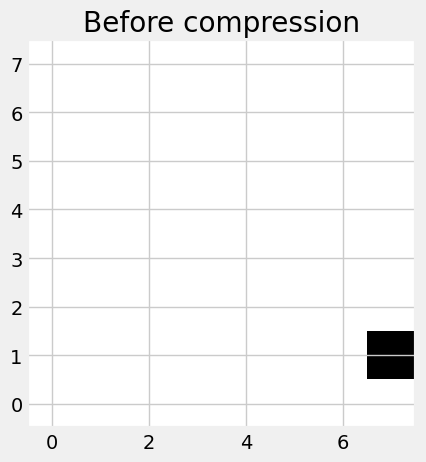

After: (1, 8, 8)
After compression


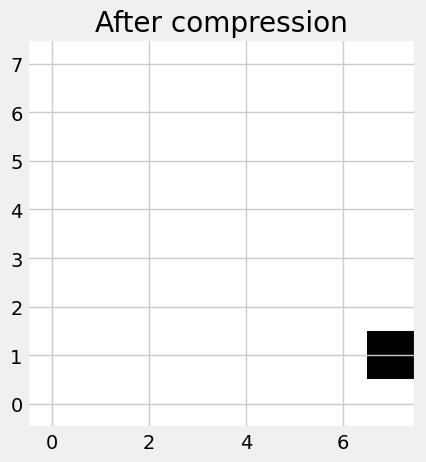

Epoch 72/80: 100%|██████████| 199/199 [00:00<00:00, 551.35it/s, Loss=0.0334]


Epoch [72/80] Average Loss: 0.0254


Epoch 73/80: 100%|██████████| 199/199 [00:00<00:00, 552.84it/s, Loss=0.0278]


Epoch [73/80] Average Loss: 0.0254


Epoch 74/80: 100%|██████████| 199/199 [00:00<00:00, 548.07it/s, Loss=0.0181]


...

Epoch [78/80] Average Loss: 0.0254


Epoch 79/80: 100%|██████████| 199/199 [00:00<00:00, 544.50it/s, Loss=0.0291]


Epoch [79/80] Average Loss: 0.0254


Epoch 80/80: 100%|██████████| 199/199 [00:00<00:00, 559.28it/s, Loss=0.0222]


Epoch [80/80] Average Loss: 0.0254
Saving trained model VAE


In [42]:
average_loss_train = []
average_loss_val = []
average_loss_kl_loss = []
patches_before = []
patches_after = []

plot_val_patches_limit = 30
plot_idx = 0

model.train()

for epoch in range(num_epochs):
    train_loss = 0
    kl_loss_total = 0
    
    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    
    for (batch_idx, X_adcs) in progress_bar:
        optimizer.zero_grad()
        
        X_adcs = X_adcs.float()
        
        # Adding some randomness for regulating the small noisy areas
        # X_adcs = X_adcs + 0.01 * torch.randn_like(X_adcs)
        
        X_adcs = X_adcs.to(device)
        
    
        (
            recon_patch, 
            mu,
            logvar 
        ) = model(
           X_adcs
        )
        
        loss, recon_loss, beta, kl_loss = _get_vae_loss(recon_patch, X_adcs, mu, logvar)
        
        recon_patch = recon_patch.float().to(device)      
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
        
        train_loss += loss.item()
        kl_loss_total += kl_loss.item()
        
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss': loss.item()})
        # scheduler.step()
        
        
    # Saving epoch  statistics
    
    avg_loss = train_loss / len(train_loader)
    print(f'Epoch [{epoch + 1}/{num_epochs}] Average Loss: {avg_loss:.4f}')
    average_loss_train.append(avg_loss)
    
    avg_loss_kl = kl_loss_total / len(train_loader)
    average_loss_kl_loss.append(avg_loss_kl)
    
    
    if epoch % LOG_EVERY == 0:
        model.eval()
        
        with torch.no_grad():            
            # selecting events before reconstruction using one test loader as validation
            total_bce_loss = 0
            patches_pairs = []
            
            for patch_val in val_loader:
                patch_val = patch_val.to(device)           
                
                (
                    recon_patch, 
                    mu,
                    logvar 
                ) = model(patch_val)
                
                # total_mse_loss += F.mse_loss(patch_val, recon_patch).item()
                total_bce_loss += F.binary_cross_entropy(patch_val, recon_patch, reduction="sum").cpu().detach().numpy().item()
                
                if len(patches_pairs) < plot_val_patches_limit:
                    patches_pairs.append((patch_val, recon_patch))
            
            average_loss = total_bce_loss / len(val_loader)
            print(f"Average validation set MSE loss: {average_loss}")
            print("Last validation batch patch mu and logvar:")
            print(
                f"mu: mean={mu.mean().item():.4f}, std={mu.std().item():.4f} | "
                f"logvar: mean={logvar.mean().item():.4f}, std={logvar.std().item():.4f}"
            )
            
            average_loss_val.append(average_loss)
            
            # print("Loss statistics:")
            # print(
            #     f"recon={recon_loss.item():.4f}, "
            #     f"kl={kl_loss.item():.4f}, " if beta > 0 else ""
            #     f"beta_kl={(beta * kl_loss).item():.4f}" if beta > 0 else ""
            # )
            
            if plot_idx < len(patches_pairs):
                patch_val_before, patch_val_after = patches_pairs[plot_idx]
                print("Before compression")
                
                patch_val_ts = _tensor_to_numpy(
                    patch_val_before.squeeze(1)
                )
                
                print(f"Before: {patch_val_ts.shape}")            
                plot_patch(patch_val_ts[0], "Before compression")
                
                patches_before.append(patch_val_ts[0])
                
                recon_patch_np = _tensor_to_numpy(
                    patch_val_after[0]
                )
                print(f"After: {recon_patch_np.shape}")
                print("After compression")
                
                plot_patch(recon_patch_np[0], "After compression")
            
                patches_after.append(recon_patch_np[0])   
                plot_idx += 1        
            
# save model
print("Saving trained model VAE")
torch.save(model.state_dict(), "vae.pth")

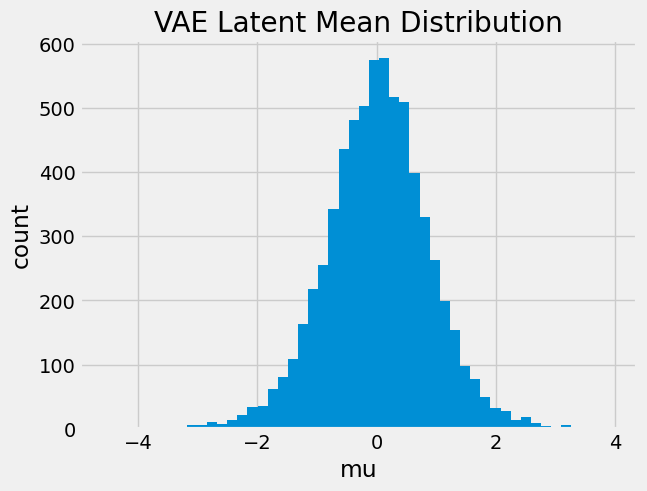

In [43]:
mu_values = mu.detach().cpu().flatten().numpy()
# histogram
plt.hist(mu_values, bins=50)

plt.title("VAE Latent Mean Distribution")
plt.xlabel("mu")
plt.ylabel("count")

plt.show()

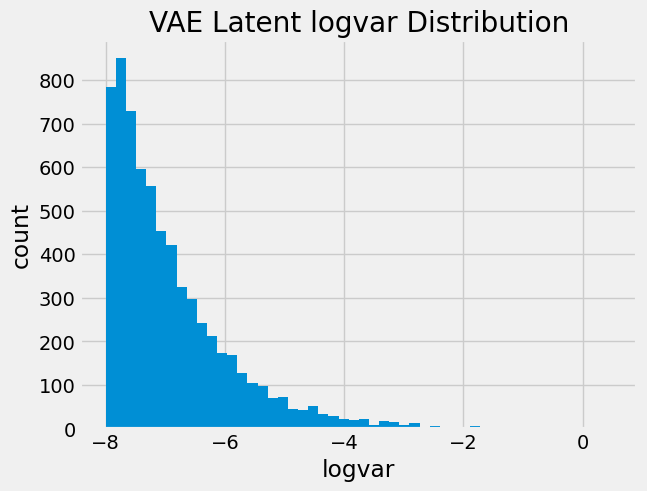

In [44]:
logvar_values = logvar.detach().cpu().flatten().numpy()
# histogram
plt.hist(logvar_values, bins=50)

plt.title("VAE Latent logvar Distribution")
plt.xlabel("logvar")
plt.ylabel("count")

plt.show()

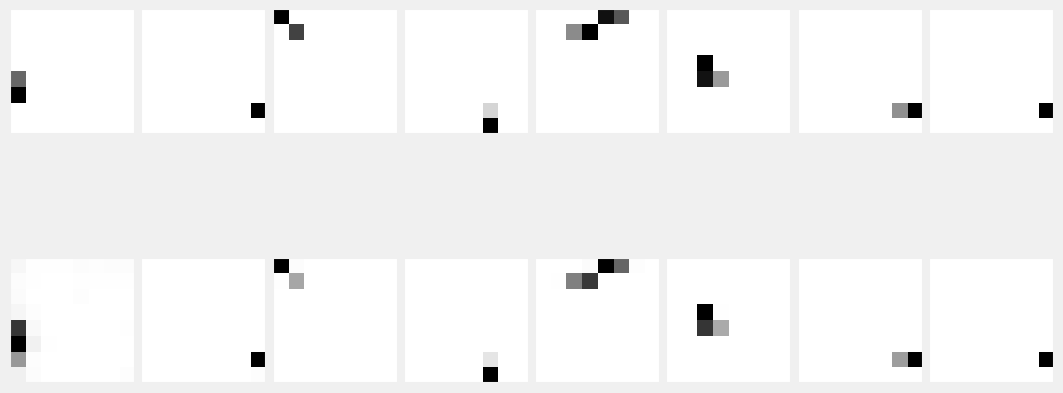

In [45]:
patch_rows = [
    patches_before,
    patches_after
]
cols = len(patch_rows[0])
rows = len(patch_rows)

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

for i in range(rows):
    for j in range(cols):
        ax = axes[i, j]
        ax.imshow(patch_rows[i][j], cmap='gist_yarg', origin='lower')
        
        ax.set_xticks([])
        ax.set_yticks([])
        
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.5)

plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.show()

In [46]:
# TODO
# Improve gradients
_display_gradients(model)

Showing model gradients
encoder.0.weight 0.016889289021492004
encoder.1.weight 0.0004882861976511776
encoder.1.bias 0.001405380549840629
encoder.3.weight 0.0028373263776302338
encoder.4.weight 0.00022671562328469008
encoder.4.bias 0.00018023925076704472
encoder.6.weight 0.0025754033122211695
encoder.7.weight 0.0002443226985633373
encoder.7.bias 0.00018330392776988447
fc_mean.weight 0.0013729496859014034
fc_mean.bias 0.0001475713652325794
fc_log_var.weight 7.65273071010597e-05
fc_log_var.bias 9.461539775657002e-06
decoder.0.weight 0.002084599807858467
decoder.1.weight 0.00024971558013930917
decoder.1.bias 0.00019930397684220225
decoder.3.weight 0.0053930035792291164
decoder.4.weight 0.0002515057858545333
decoder.4.bias 0.0002624309854581952
decoder.6.weight 0.0019437791779637337


/tmp/ipykernel_2981887/1764288248.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


VAE, Average loss values over epochs


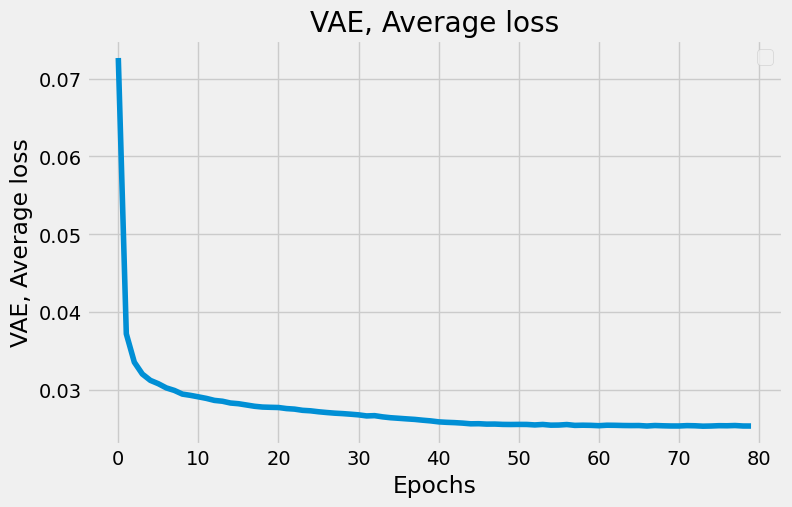

In [47]:
# display loss values
plot_metric_results(
    y_values=average_loss_train, 
    x_values=list(range(num_epochs)),
    y_title="VAE, Average loss",
    title="VAE, Average loss",
    x_label="Epochs"
)

In [48]:
print(f"mu = {model.z_log_mean.mean().item()}")
print(f"logvar = {model.z_log_var.std().item()}")

mu = 0.017725883051753044
logvar = 1.0504956245422363


In [49]:
# Test set for testing using unseen data
model.load_state_dict(torch.load("vae.pth"))
model.eval()

bce_loss_values_test = []

patch_display_limit = 8
patches_after_test = []
patches_before_test = []


for patch_test in test_loader:
    patch_test = patch_test.to(device)                     
    (
        recon_patch, 
        mu,
        logvar 
    ) = model(patch_test)
    
    if len(patches_after_test) < patch_display_limit:
        patch_test_np = patch_test[0][0].cpu().detach().numpy()
        patches_before_test.append(patch_test_np)
        
        recon_patch_np = recon_patch[0][0].cpu().detach().numpy()
        patches_after_test.append(recon_patch_np)
    
    # mse_loss = F.mse_loss(patch_test, recon_patch).item()
    bce_loss = F.binary_cross_entropy(patch_test, recon_patch, reduction="sum").cpu().detach().numpy().item()
    bce_loss_values_test.append(bce_loss)

In [50]:
len(patches_before_test)

8

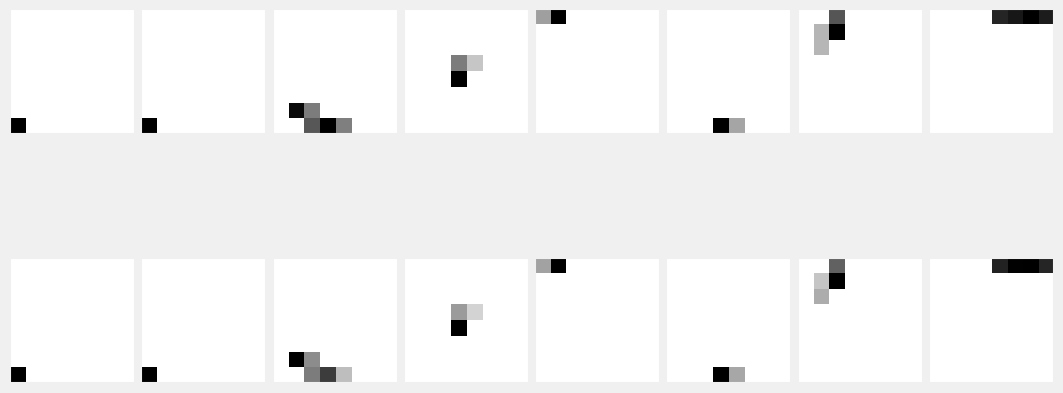

In [51]:
# Test dataset plotting part
patch_rows = [
    patches_before_test,
    patches_after_test
]
cols = len(patch_rows[0])
rows = len(patch_rows)

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

for i in range(rows):
    for j in range(cols):
        ax = axes[i, j]
        ax.imshow(patch_rows[i][j], cmap='gist_yarg', origin='lower')
        
        ax.set_xticks([])
        ax.set_yticks([])
        
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.5)

plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.show()

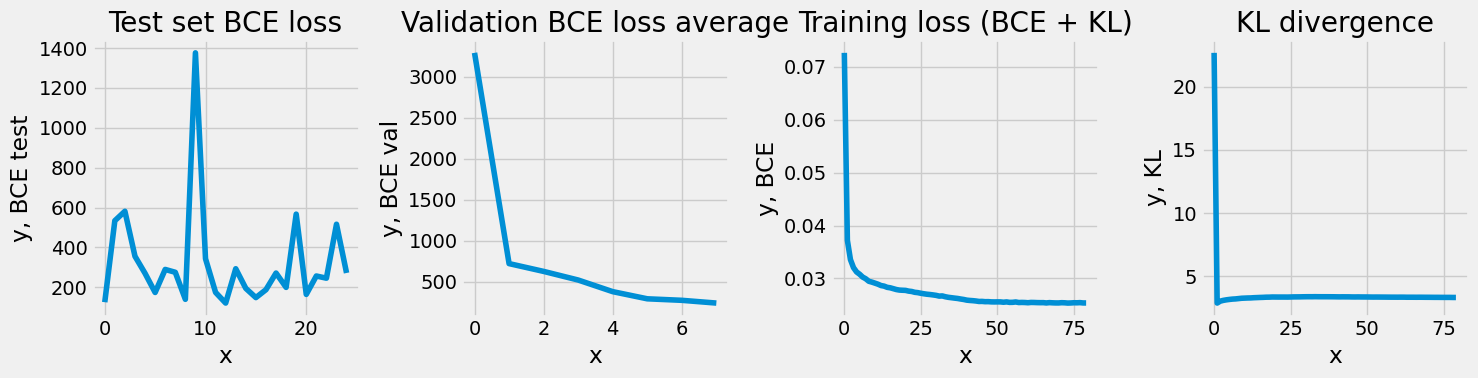

In [52]:
values_to_plot = [
    (list(range(len(bce_loss_values_test))), bce_loss_values_test, "Test set BCE loss", "BCE test"),
    (list(range(len(average_loss_val))), average_loss_val, "Validation BCE loss average", "BCE val"),
    (list(range(len(average_loss_train))), average_loss_train, "Training loss (BCE + KL)", "BCE"),
    (list(range(len(average_loss_kl_loss))), average_loss_kl_loss, "KL divergence", "KL")
]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for i, (x, y, title, y_label) in enumerate(values_to_plot):
    axes[i].plot(
        x,
        y,
    )
    axes[i].grid(True)
    axes[i].set_title(title)
    axes[i].set_xlabel("x")
    axes[i].set_ylabel(f"y, {y_label}")
    
    for spine in axes[i].spines.values():
        spine.set_linewidth(2)

plt.tight_layout()
plt.show()

# print(title + " values over epochs")
# plt.style.use('fivethirtyeight')
# plt.figure(figsize=(8, 5))
# plt.plot(x_values, y_values, marker=marker)
# plt.xlabel(x_label)
# plt.ylabel(y_title)
# plt.legend()
# plt.title(title)
# plt.show()

Comments
* Based on the current results,
the closer the Z latent space values are to the prior (Normal distribution),
the less stable VAE model becomes

* The more KL divergence increases, the reconstruction quality significantly drops

* If the reconstruction quality improves, z distribution becomes almost like gaussian and loss function starts to slow down after 5 epochs

* If 10 and -10 extreme values dissapear, then loss does not fall to quickly and reconstruction quality improves

* 10 and -10 extreme values appear due to high learning rate. Lerning_rate = 1e-2

* Since KL divergence is constantly growing, very small beta (scale factor) is required for the KL divergence

* Increase of latent space and hidden dimensions, marginally improved loss function

* Used 0002.root file pixel digi events